# ECサイトにおける利益改善のための購買分析

### 目的
- ECサイトの商品データを分析し、利益の高いカテゴリや購買傾向を把握する。
- ユーザー情報や価格帯、時系列別に分析を行い利益改善につながる分析をする。

### 使用ライブラリ
- SQL(Bigquery)
- Python
- pandas
- matplotlib
- seaborn

### 分析内容
- 1~6章に分類し、利益改善のための分析を行う。
1. カテゴリ別利益分析
2. 時系列分析
3. ユーザー分析
4. 価格帯分析
5. 改善案

### データの前処理

- データの読み込み
- ライブラリのインポート
- 分散、標準偏差、平均値などの数値確認
- 外れ値の有無確認

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

df_profit = pd.read_csv(r"C:\Users\gaku2\study\pandas\thelook_ecommerce\profit_data.csv")
df_user = pd.read_csv(r"C:\Users\gaku2\study\pandas\thelook_ecommerce\user_data.csv")
df_monthly = pd.read_csv(r"C:\Users\gaku2\study\pandas\thelook_ecommerce\monthly_data.csv")
df_data = pd.read_csv(r"C:\Users\gaku2\study\pandas\thelook_ecommerce\about_clothes_data.csv")
plt.rcParams["font.family"] = "Meiryo"
plt.rcParams["axes.unicode_minus"] = False



In [2]:
df_profit.describe()

,order_count,country_count,avg_sale_price,price_std,total_profit,avg_profit_rate
count,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000
mean,1109.006211,10.807453,174.473665,27.740306,34810.141864,51.127635
std,1538.077170,2.606520,178.865996,45.809840,34141.277342,7.296084
min,4.000000,2.000000,15.882022,0.000000,358.902490,36.200000
25%,63.000000,10.000000,66.070553,11.163561,6961.815174,45.736496
50%,410.000000,12.000000,135.203919,15.207227,24550.185717,51.200000
75%,1625.000000,12.000000,245.333333,26.975765,53920.855245,57.898582
max,10707.000000,15.000000,927.000000,301.147236,169597.208372,63.800000


In [3]:
df_user.describe()

,order_count,total_price,avg_price
count,216.000000,216.000000,216.000000
mean,835.833333,49731.417130,62.576273
std,596.821238,42944.691064,32.441679
min,7.000000,731.620007,14.000700
25%,412.000000,17790.552521,41.208022
50%,801.500000,39563.195076,50.944835
75%,1084.250000,65349.160031,79.138367
max,4104.000000,269540.509531,160.857363


In [4]:
df_monthly.describe()

,order_count,monthly_sales,avg_price
count,2244.000000,2244.000000,2244.000000
mean,80.817736,4800.467746,60.597747
std,107.115478,7430.328834,35.952481
min,1.000000,8.470000,8.470000
25%,14.000000,711.702496,36.161102
50%,43.000000,2205.900007,51.311029
75%,105.000000,5802.367505,77.805000
max,976.000000,96211.870092,360.000000


In [5]:
print(df_profit.isnull().sum())
print(df_user.isnull().sum())
print(df_monthly.isnull().sum())

category           0
gender             0
order_count        0
country_count      0
avg_sale_price     0
price_std          0
total_profit       0
avg_profit_rate    0
price_group        0
dtype: int64
age_group      0
gender         0
category       0
order_count    0
total_price    0
avg_price      0
dtype: int64
category         0
order_month      0
order_count      0
monthly_sales    0
avg_price        0
dtype: int64


SQL(Bigquery)でデータ処理をしたため、欠損値はなかった。まず初めに1章のカテゴリ別の利益分析を行う。

## 1章：カテゴリ別の利益分析

In [6]:
df_profit

,category,gender,order_count,country_count,avg_sale_price,price_std,total_profit,avg_profit_rate,price_group
0,Outerwear & Coats,M,2110,13,143.088770,28.399907,169597.208372,55.570939,中価格
1,Jeans,M,2237,12,155.241813,28.462380,164328.152592,46.797391,中価格
2,Outerwear & Coats,M,470,12,500.994532,204.779532,132322.275977,56.207021,高価格
3,Intimates,F,10707,14,25.005956,11.748512,131936.790885,46.955811,低価格
4,Suits & Sport Coats,M,1336,12,150.658579,28.700411,121649.424436,60.117498,中価格
...,...,...,...,...,...,...,...,...,...
156,Jumpsuits & Rompers,F,7,4,216.514284,14.325204,731.968797,48.371429,中高価格
157,Socks & Hosiery,F,7,2,159.949997,0.000000,714.336687,63.800000,中価格
158,Suits,F,76,10,23.498947,4.897724,702.790694,39.339474,低価格
159,Socks,M,14,5,114.974998,5.162800,589.758738,36.600000,中価格


In [7]:
df_profit["avg_profit_rate"].mean()

np.float64(51.12763485403589)

分かったこと
- 全カテゴリの平均利益率は50.79程であることを踏まえるとJeans,Swim,Fashion Hoodies & Sweatshirts, Tops & Tees,Intimatesは売上個数が多いのにも関わらず、平均利益率が低いことから個数の割に売り上げが伸びていないことがわかる。
- Blazers & Jackets,Socks & Hosiery,Accessories,Suits & Sport などは利益率が高いことが分かる。

---

考察
- 商品の売れる時期によって売れる商品と売れにくい商品がある。
- 生活をするなかで、頻繁に使用するものかどうかが関わっているのではないかと考える。


## 2章：時系列分析

In [8]:
df_monthly.head(30)

,category,order_month,order_count,monthly_sales,avg_price
0,Jeans,2026-05-01,976,96211.870092,98.577736
1,Outerwear & Coats,2026-05-01,653,91263.669930,139.760597
2,Sweaters,2026-05-01,860,62907.740002,73.148535
3,Outerwear & Coats,2026-04-01,396,59021.809980,149.044975
4,Outerwear & Coats,2026-03-01,377,58218.869896,154.426711
5,Jeans,2026-04-01,584,56214.740118,96.258117
6,Jeans,2026-03-01,533,51755.040140,97.101389
7,Outerwear & Coats,2026-02-01,337,49360.879971,146.471454
8,Fashion Hoodies & Sweatshirts,2026-05-01,908,49141.410030,54.120496
9,Swim,2026-05-01,839,47569.050090,56.697318


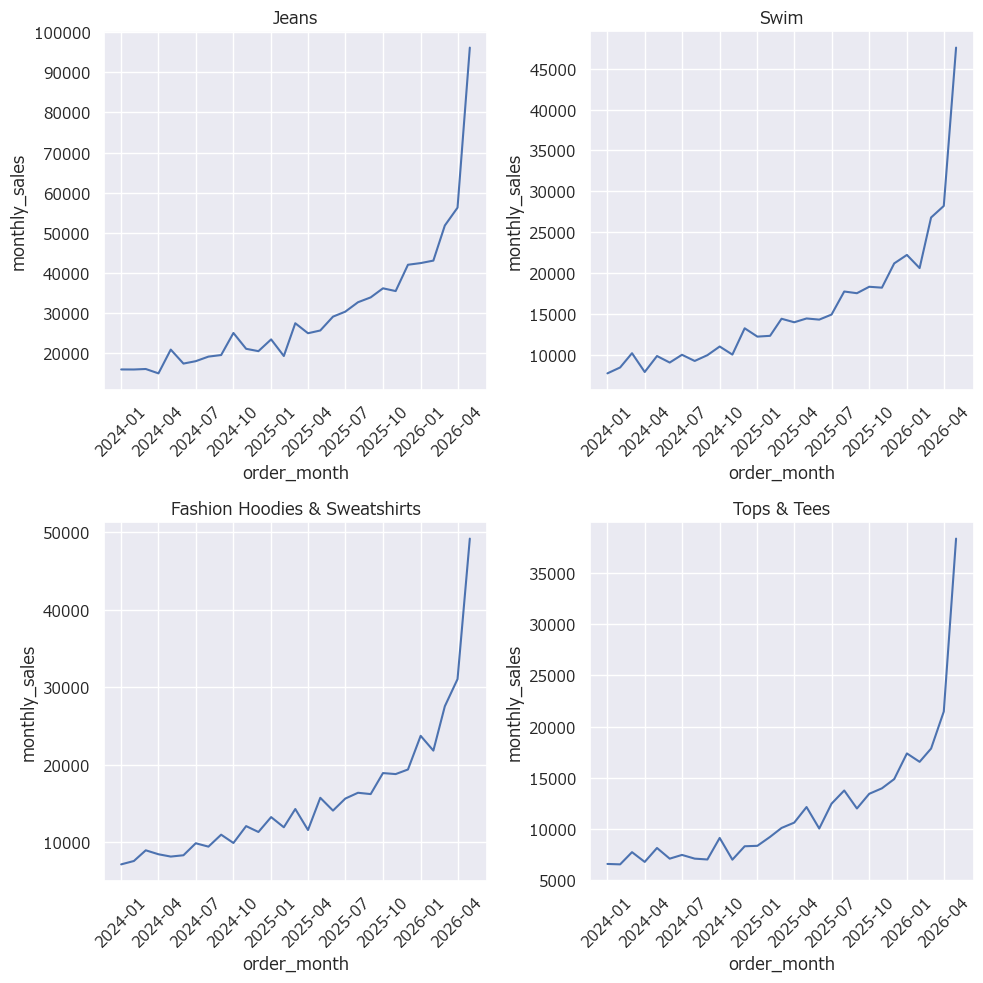

In [9]:
df_monthly["order_month"] = pd.to_datetime(
    df_monthly["order_month"]
)

target_categories = [
    "Jeans",
    "Swim",
    "Fashion Hoodies & Sweatshirts",
    "Tops & Tees"
]

target_df = df_monthly[
    df_monthly["category"].isin(target_categories)
]

target_df = target_df.sort_values("order_month")

target_df = target_df[
    target_df["order_month"] >= "2024-01-01"
]

fig, axes = plt.subplots(
    2, 2,
    figsize=(10,10)
)

axes = axes.flatten()

for i, cat in enumerate(target_categories):

    temp = target_df[
        target_df["category"] == cat
    ]

    sns.lineplot(
        data=temp,
        x="order_month",
        y="monthly_sales",
        ax=axes[i]
    )

    axes[i].set_title(cat)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

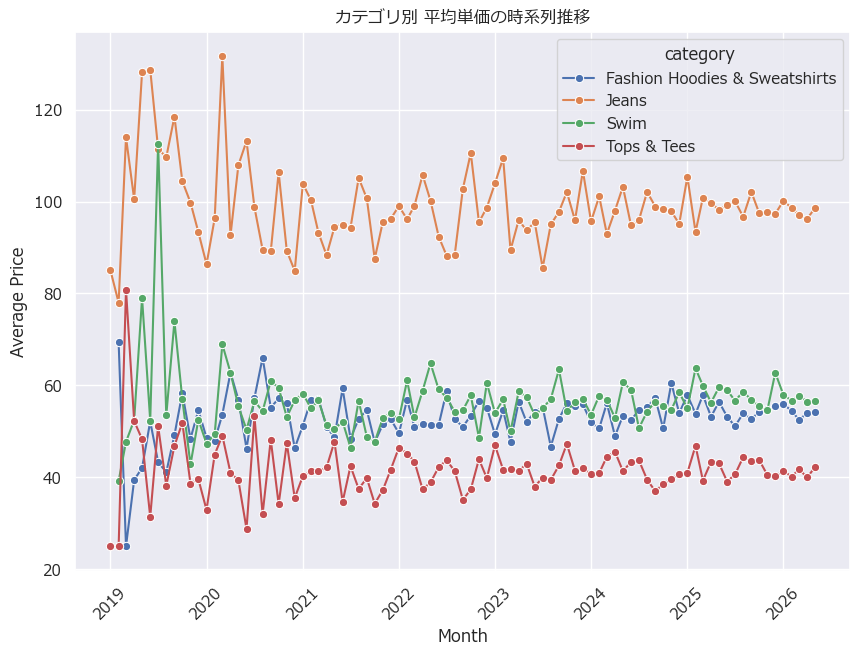

In [10]:
target_categories = [
    "Jeans",
    "Swim",
    "Fashion Hoodies & Sweatshirts",
    "Tops & Tees"
]

target_df = df_monthly[
    df_monthly["category"].isin(target_categories)
].copy()

target_df["order_month"] = pd.to_datetime(
    target_df["order_month"]
)

target_df = target_df.sort_values(
    ["category", "order_month"]
)

plt.figure(figsize=(10,7))

sns.lineplot(
    data=target_df,
    x="order_month",
    y="avg_price",
    hue="category",
    marker="o"
)

plt.title("カテゴリ別 平均単価の時系列推移")
plt.xlabel("Month")
plt.ylabel("Average Price")

plt.xticks(rotation=45)

plt.show()

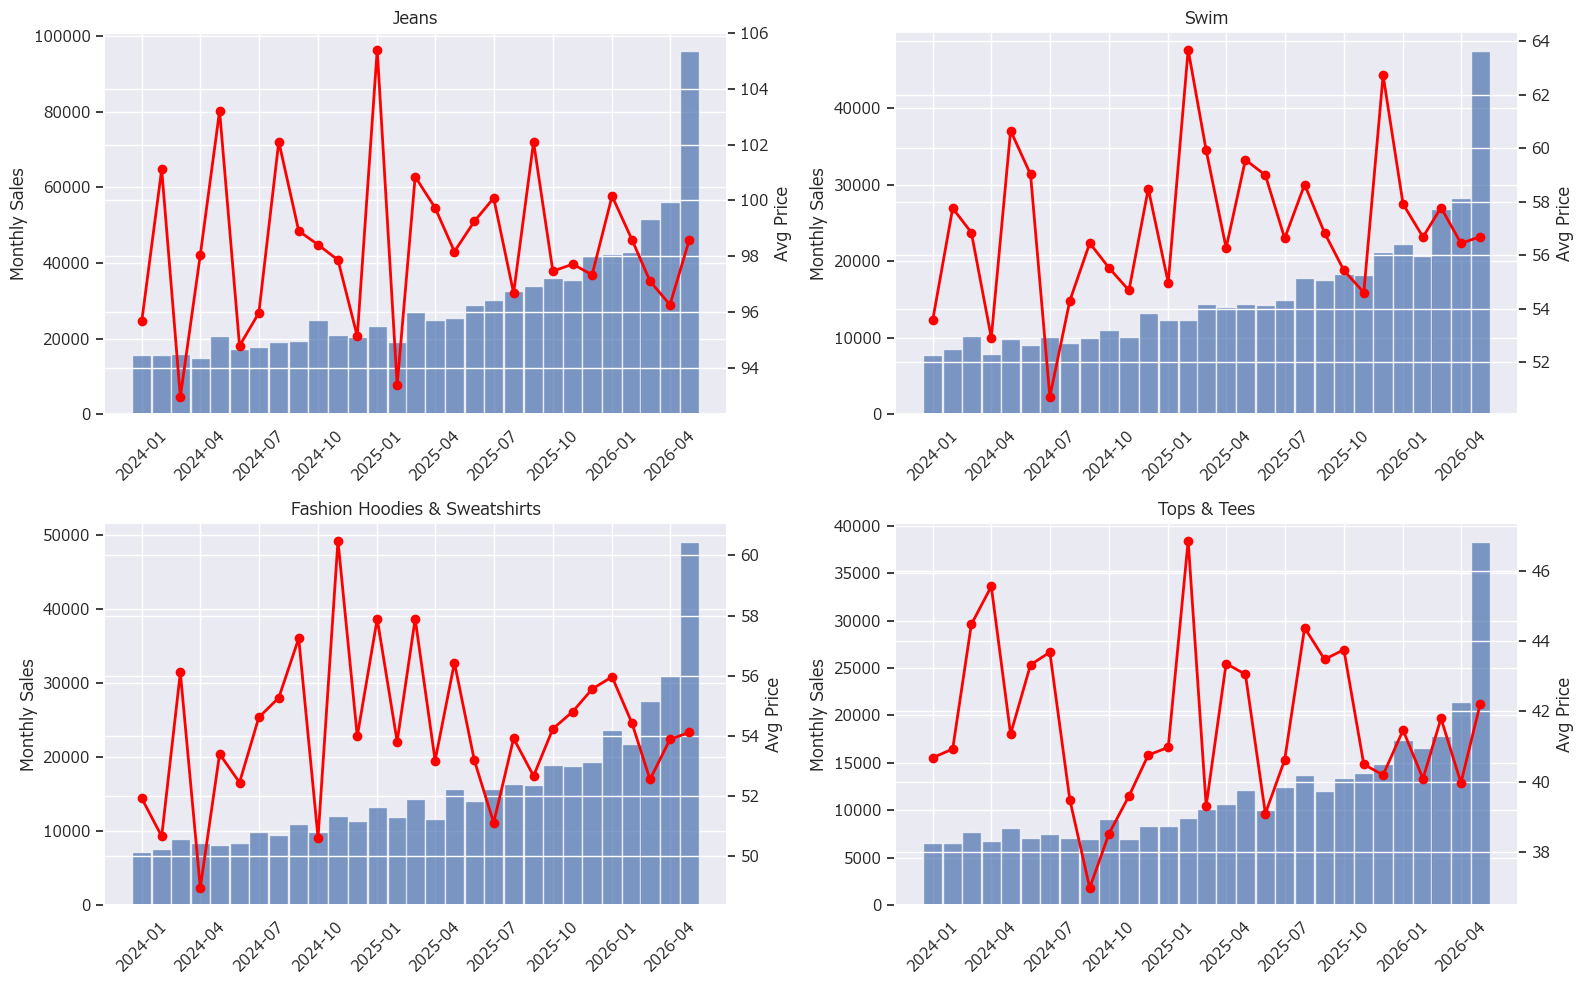

In [11]:
target_categories = [
    "Jeans",
    "Swim",
    "Fashion Hoodies & Sweatshirts",
    "Tops & Tees"
]

target_df = df_monthly[
    df_monthly["category"].isin(target_categories)
].copy()

target_df["order_month"] = pd.to_datetime(
    target_df["order_month"]
)

target_df = target_df[
    target_df["order_month"] >= "2024-01-01"
]

target_df = target_df.sort_values(
    ["category", "order_month"]
)

fig, axes = plt.subplots(
    2, 2,
    figsize=(16,10)
)

axes = axes.flatten()

for i, cat in enumerate(target_categories):

    temp = target_df[
        target_df["category"] == cat
    ]

    axes[i].bar(
        temp["order_month"],
        temp["monthly_sales"],
        alpha=0.7,
        width=30
    )

    ax2 = axes[i].twinx()

    ax2.plot(
        temp["order_month"],
        temp["avg_price"],
        color="red",
        marker="o",
        linewidth=2
    )

    axes[i].set_title(cat)

    axes[i].set_ylabel("Monthly Sales")

    ax2.set_ylabel("Avg Price")

    axes[i].tick_params(
        axis="x",
        rotation=45
    )

plt.tight_layout()

plt.show()

分かったこと
- 月によって売値の平均金額が変動しているが、売り上げにはあまり変化はない。
- 2026年以降に売上増加が見られたが、要因については追加調査が必要である。
- 季節の変わり目で売り上げが上がっているのが見られる。
---
考察
- 衣替えなどの大きく衣服を交換する時期と関係がある可能性あり。

## 3章：ユーザー分析

In [12]:
df_user.head()

,age_group,gender,category,order_count,total_price,avg_price
0,50代,M,Outerwear & Coats,1808,269540.509531,149.082140
1,50代,M,Jeans,2479,244539.999943,98.644615
2,50代,M,Suits & Sport Coats,1635,202865.299735,124.076636
3,50代,M,Sweaters,2094,160274.010022,76.539642
4,50代,F,Outerwear & Coats,1084,154164.000126,142.217712


In [13]:
print(df_user.groupby("gender")["order_count"].sum())
print(df_user.groupby("gender")["order_count"].count())

gender
F    90541
M    89999
Name: order_count, dtype: int64
gender
F    132
M     84
Name: order_count, dtype: int64


In [14]:
print(df_user.groupby("gender")["total_price"].mean())
print(df_user.groupby("gender")["avg_price"].mean())

gender
F    38308.419288
M    67681.842310
Name: total_price, dtype: float64
gender
F    61.261378
M    64.642538
Name: avg_price, dtype: float64


In [15]:
top10_order_count= df_user.sort_values(
    "order_count",
    ascending=False
).head(10)

top10_order_count.groupby("age_group")["order_count"].sum()

age_group
20代     2289
30代     2290
40代     2279
50代    17940
Name: order_count, dtype: int64

In [16]:
top_order_count= df_user.sort_values(
    "order_count",
    ascending=False
)
order_percent_count = top_order_count.groupby("age_group")["order_count"].sum()

(order_percent_count / order_percent_count.sum()) * 100

age_group
10代      13.976404
20代      17.077102
30代      16.819541
40代      16.730918
50代      31.928105
60代以上     3.467930
Name: order_count, dtype: float64

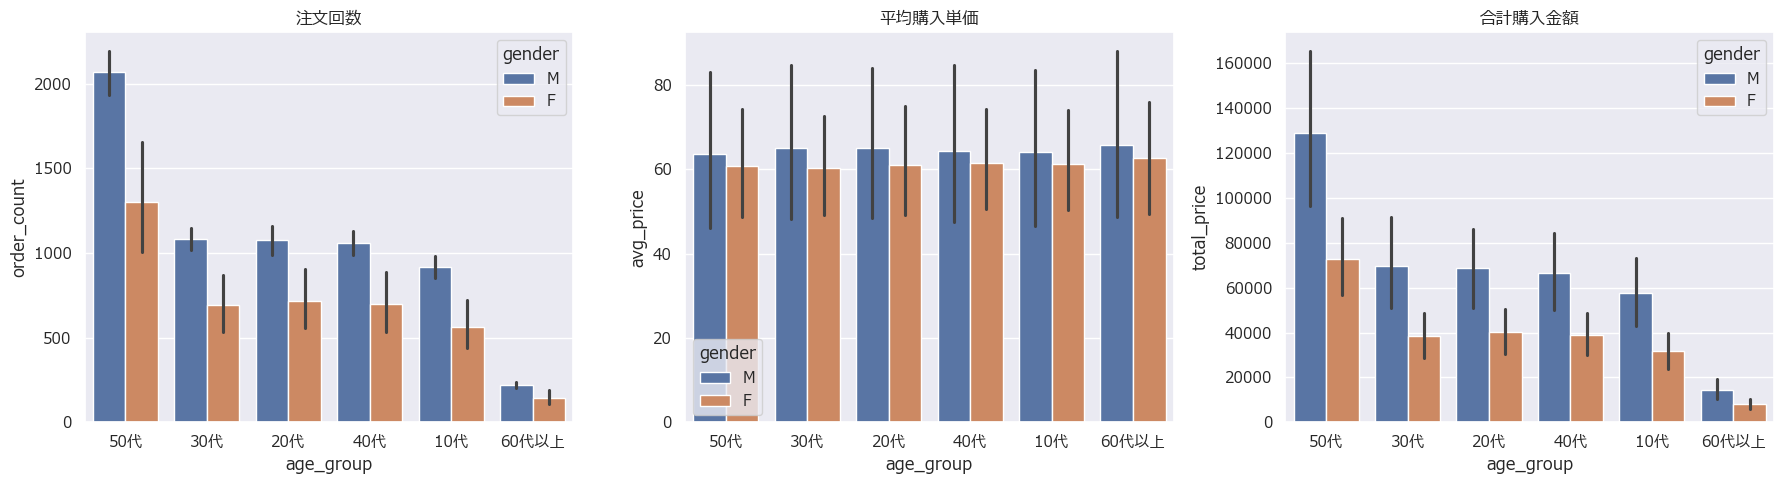

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    data=df_user,
    x="age_group",
    y="order_count",
    hue="gender",
    ax=axes[0]
)
axes[0].set_title("注文回数")

sns.barplot(
    data=df_user,
    x="age_group",
    y="avg_price",
    hue="gender",
    ax=axes[1]
)
axes[1].set_title("平均購入単価")

sns.barplot(
    data=df_user,
    x="age_group",
    y="total_price",
    hue="gender",
    ax=axes[2]
)
axes[2].set_title("合計購入金額")

plt.tight_layout()
plt.show()

分かったこと
- 注文数にはあまり差がないが、女性のほうが購入する商品の種類が多かった。しかし、総合の金額は男性の方が圧倒的に多い。
- 年代ごとの購入数でみると50代の購入が全体の30%を占めていることが分かる。
- グラフを見ると、平均金額にはあまり差がないことが分かる。
---
考察
- いかに50代の客層にあった商品を提供するかで売り上げが大きく変わる。
- 利益を伸ばすには50代にあった商品の値段を伸ばすことやコストを抑え、利益率を上げることが重要だと考える。

## 4章：価格帯分析

In [18]:
df_profit.head(20)

,category,gender,order_count,country_count,avg_sale_price,price_std,total_profit,avg_profit_rate,price_group
0,Outerwear & Coats,M,2110,13,143.088770,28.399907,169597.208372,55.570939,中価格
1,Jeans,M,2237,12,155.241813,28.462380,164328.152592,46.797391,中価格
2,Outerwear & Coats,M,470,12,500.994532,204.779532,132322.275977,56.207021,高価格
3,Intimates,F,10707,14,25.005956,11.748512,131936.790885,46.955811,低価格
4,Suits & Sport Coats,M,1336,12,150.658579,28.700411,121649.424436,60.117498,中価格
5,Jeans,F,1621,12,152.201303,29.989184,114503.802150,45.948135,中価格
6,Pants,M,2866,13,68.728519,14.024242,107736.153970,54.168957,中低価格
7,Suits & Sport Coats,M,689,13,248.654248,25.673753,103007.856676,59.852312,中高価格
8,Outerwear & Coats,F,1231,12,139.009444,28.009506,94803.673443,54.997097,中価格
9,Underwear,M,6911,15,24.889403,7.724502,94758.948377,52.968890,低価格


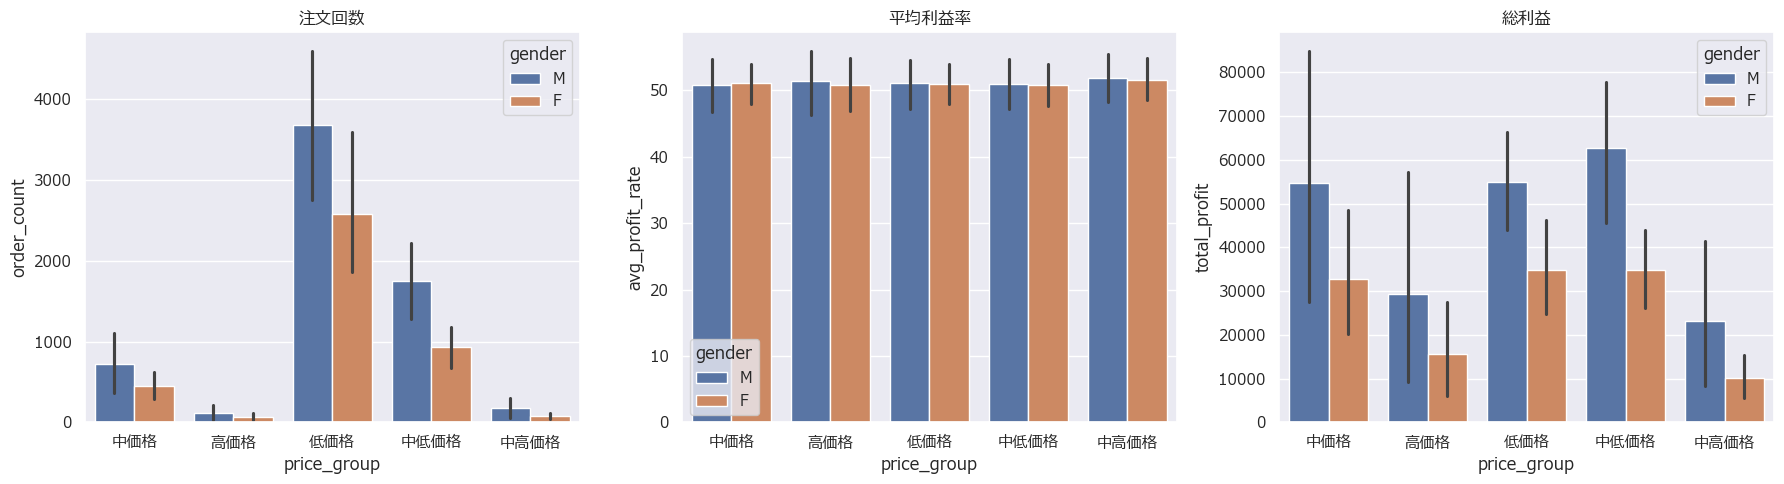

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    data=df_profit,
    x = "price_group",
    y = "order_count",
    hue="gender",
    ax=axes[0]
)
axes[0].set_title("注文回数")
sns.barplot(
    data=df_profit,
    x = "price_group",
    y = "avg_profit_rate",
    hue="gender",
    ax=axes[1]
)
axes[1].set_title("平均利益率")

sns.barplot(
    data=df_profit,
    x = "price_group",
    y = "total_profit",
    hue="gender",
    ax=axes[2]
)
axes[2].set_title("総利益")

plt.tight_layout()
plt.show()

In [20]:
df_years = df_user[["age_group", "avg_price"]].copy()

df_years["price_group"] = pd.cut(
    df_years["avg_price"],
    bins=[0, 25, 50, 75, 100, 150,(df_years["avg_price"].max())],
    labels=[
        "0-25ドル",
        "25-50ドル",
        "50-75ドル",
        "75-100ドル",
        "100-150ドル",
        "150ドル以上"
    ],
    include_lowest=True
)

pd.crosstab(
    df_years["age_group"],
    df_years["price_group"]
)

price_group,0-25ドル,25-50ドル,50-75ドル,75-100ドル,100-150ドル,150ドル以上
age_group,,,,,,
10代,2,16,8,5,5,0
20代,2,15,9,5,5,0
30代,2,14,10,5,5,0
40代,2,14,11,4,5,0
50代,2,15,9,6,4,0
60代以上,2,14,10,3,6,1


分かったこと
- 注文回数は低価格と中低価格に多く分布し、総利益は低価格、中低価格、中価格に多く分布している。
- 利用者の多くが25～50ドルの価格帯であり、これは低価格に分類される。中低価格は100ドルまでであり、こちらも利用者が多いことが分かる。
---
考察
- 価格帯の25$～100$までの商品を購入させるように商品の種類を増やすことが大切なのでは。
- 総利益だけで見ると男性の利益が大きいので中価格の50$～200$までの商品を増やす。

## 5章：改善提案

### 提案１
- 施策：下着、靴下、Tシャツなどの比較的安価な商品を多く提供することで気軽に商品を購入することを狙う。またSNSだけでなく複数チャネルでの広告展開を検討する。
- ターゲット：全ユーザー(50代に注力)
- 期待効果：ついで買いによる購入点数の増加

### 提案2
- 施策：季節の変わり目のタイミングで売りに出す商品を増やす。（主に7月、1月）（スポーツウェアやスーツ）
- ターゲット：スポーツウェアやスーツの需要増加が予想される顧客層
- 期待効果：季節需要を捉えた売上・利益の向上
### 提案3
- 施策：アクセサリーなど高単価商品になりえるラインナップを拡充する小物目当てのユーザーを増やす。
- ターゲット：10代～20代(女性メイン)
- 期待効果：若年層ユーザーの追加獲得

1. 提案1はユーザーの年代で30%を占めている50代に焦点をあてた施策をとる。全年代にもかかわることだが、1つの値段が100$以内の商品を買うという傾向があるので、下着や靴下、Tシャツなどの比較的安価な商品を多く提供することで気軽に商品を購入することを狙う。またSNSだけでなく複数チャネルでの広告展開を検討する。

2. 提案2は夏や冬などの変わり目に売り上げが少し伸びている傾向が見られたので、ターゲットは社会人男性を目的とし、スポーツウェアやスーツの需要増加が予想されるカテゴリの在庫や広告を強化する。また、単価も他の商品と比べ高いので利益に大きな貢献をすると考える。ユーザー視点では、目当ての商品を買いに店に来るが、提案1でも示したように下着や日用品の価格を下げることでついでに下着も買うなど目当てではないものとして付随での購入も狙う。

3. 提案3についてだが、現段階では、10代や20代のユーザーが少ない。そこで、その年代のユーザーも増やしていくことで多種多様な店であることが広まり、利益の底上げを期待する。今回はターゲットを若者の女性に絞る。衣類などの洋服がメインの店だが、その中でもアクセサリーはコーディネートとセットで買うことがあるので、アクセサリーの種類を増やす。また、安価な商品のみを販売すると期待に応えられない場合が出てくる可能性があるため、ある程度高額なアクセサリーを用意し、まずはその商品に注目させる。その後、見た目は似ているが比較的安価な商品を置いておくことで安い方を購入させることを狙う。